In [35]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [6]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

d:\LangGraph-end-to-end\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--BAAI--bge-small-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
!pip install langchain-text-splitters

In [16]:
# Creating the Retriever
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma

In [ ]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

In [18]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300,
    chunk_overlap=50,
)

In [19]:
doc_splits=text_splitter.split_documents(docs_list)

In [22]:
# Add documents to the vector store
vectorstore=Chroma.from_documents(
    documents=doc_splits,
    embedding=embeddings,
    collection_name='rag-chroma',
)

In [64]:
retriever = vectorstore.as_retriever()

In [27]:
retriever.invoke('what is prompt engineering?')

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/', 'title': "Prompt Engineering | Lil'Log", 'language': 'en', 'description': 'Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the model weights. It is an empirical science and the effect of prompt engineering methods can vary a lot among models, thus requiring heavy experimentation and heuristics.\nThis post only focuses on prompt engineering for autoregressive language models, so nothing with Cloze tests, image generation or multimodality models. At its core, the goal of prompt engineering is about alignment and model steerability. Check my previous post on controllable text generation.'}, page_content='Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the mode

In [ ]:
# creating RAG chain
from langsmith import Client

client = Client()  
prompt = client.pull_prompt("rlm/rag-prompt")  

In [30]:
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

In [31]:
# post processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [36]:
# chain
from langchain_core.output_parsers import StrOutputParser
rag_chain=prompt | llm| StrOutputParser()

In [33]:
rag_chain

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])
| ChatGroq(profile={'max_input_tokens': 262144, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.res

In [37]:
# Testing RAG chain
question="What is prompt engineering and how does it helpful for LLMs?"
generation=rag_chain.invoke(
    {'context':docs, 'question':question}
)
print(generation)

Prompt engineering refers to methods for communicating with large language models (LLMs) to steer their behavior for desired outcomes without updating the model weights. It is helpful for LLMs as it enables users to elicit specific responses, improve performance on complex tasks, and align the model's output with human intentions. Effective prompt engineering can be done through techniques such as few-shot learning, chain-of-thought prompting, and using external tools or APIs.


creating grade document class

In [60]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field


class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

In [61]:
# LLM with function call
structured_llm_grader = llm.with_structured_output(GradeDocuments)
# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

In [66]:
question = "tell me about the agent memory."
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


In [67]:
question = "tell me about the Tajmahal."
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='no'


Creating question Re-writer to test

In [101]:
from langchain_core.prompts import ChatPromptTemplate

system = """You are a search query rewriter.
Rewrite the user's question into ONE short web-search query.
Return only the rewritten query text.
Do not add explanations, bullets, or extra sentences."""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Original question: {question}\nRewritten search query:",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()

In [116]:
question="what is prompt engineering? and how it is helpful for LLMs? and users?"

In [117]:
question_rewriter.invoke({"question": question})

'"what is prompt engineering and its benefits for LLMs and users"'

In [73]:
# creating functions for the nodes
def retrieve(state):
    """
    Retrieves relevant documents based on the question..
    Args:
        state (dict): The current state of the graph, containing the question and context.
    Returns:
    """
    print("---Retriever Node---")
    question=state['question']
    documents=retriever.invoke(question)
    
    return {'documents': documents, 'question': question}
    

In [53]:
def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """
    
    print("---CHECKING DOCUMENT RELEVANT IS TO QUESTION OR NOT---")
    
    question = state["question"]
    
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    
    web_search = "No"
    
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}

In [52]:
def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    
    print("---GENERATE---")
    
    question = state["question"]
    documents = state["documents"]
    
    generation = rag_chain.invoke({"context": documents, "question": question})
    
    return {"documents": documents, "question": question, "generation": generation}

In [102]:
def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """
    print("---TRANSFORM QUERY---")
    
    question = state["question"]
    documents = state["documents"]

    # Re-write question and sanitize to a single-line search query.
    better_question = question_rewriter.invoke({"question": question})
    better_question = better_question.strip().splitlines()[0].strip("\"' ")[:200]
    
    return {"documents": documents, "question": better_question}

Web Crawling is perform using Tavily

In [46]:
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

C:\Users\USER\AppData\Local\Temp\ipykernel_14444\1505316070.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


In [124]:
from langchain_core.documents import Document
def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """
    print("---WEB SEARCH---")
    
    question = state["question"]
    documents = state["documents"]

    # Get web search results and pass directly to LLM
    results = web_search_tool.invoke({"query": question})
    documents.append(Document(page_content=str(results)))

    return {"documents": documents, "question": question}

In [50]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """
    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [39]:
# Creating RAG chain with LangGraph
from langgraph.graph import StateGraph, END, START

In [40]:
from typing import List
from typing_extensions import TypedDict

In [119]:
class State(TypedDict):
    """
    Represents the state of our graph.
    
    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """
    
    question: str
    generation: str
    web_search: str
    documents: List[str]
    
workflow= StateGraph(State)

In [120]:
# defining the nodes
workflow.add_node('retriever', retrieve)
workflow.add_node('grade_documents', grade_documents) 
workflow.add_node('generate', generate)
workflow.add_node('transform_query', transform_query)
workflow.add_node('web_search_node', web_search)

In [121]:
# define the graph edges
workflow.add_edge(START, 'retriever')
workflow.add_edge('retriever', 'grade_documents')
workflow.add_conditional_edges('grade_documents', decide_to_generate, {'transform_query': 'transform_query', 'generate': 'generate'})
workflow.add_edge('transform_query', 'web_search_node')
workflow.add_edge('web_search_node', 'generate')
workflow.add_edge('generate', END)

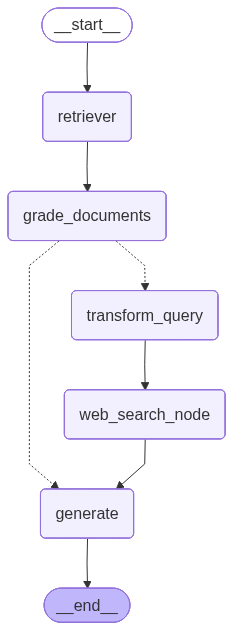

In [122]:
app=workflow.compile()
app

In [71]:
from pprint import pprint

# Run
inputs = {"question": "tell me about the agent memory."}

In [81]:
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")
# Final generation
pprint(value["generation"])

---Retriever Node---
"Node 'retriever':"
'\n---\n'
---CHECKING DOCUMENT RELEVANT IS TO QUESTION OR NOT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
"Node 'grade_documents':"
'\n---\n'
---GENERATE---
"Node 'generate':"
'\n---\n'
('The agent memory consists of short-term memory and long-term memory. '
 'Short-term memory utilizes in-context learning to learn, while long-term '
 'memory retains and recalls infinite information over extended periods using '
 'an external vector store and fast retrieval. The memory stream, a long-term '
 "memory module, records a comprehensive list of agents' experiences in "
 'natural language.')


In [125]:
from pprint import pprint

# Run
inputs = {"question": "tell me about the LangGraph."}

In [126]:
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")
# Final generation
pprint(value["generation"])

---Retriever Node---
"Node 'retriever':"
'\n---\n'
---CHECKING DOCUMENT RELEVANT IS TO QUESTION OR NOT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
"Node 'grade_documents':"
'\n---\n'
---TRANSFORM QUERY---
"Node 'transform_query':"
'\n---\n'
---WEB SEARCH---
"Node 'web_search_node':"
'\n---\n'
---GENERATE---
"Node 'generate':"
'\n---\n'
('LangGraph is a library within the LangChain ecosystem that provides a '
 'framework for defining, coordinating, and executing multiple LLM agents in a '
 'structured and efficient manner. It uses graph-based architectures to model '
 'and manage AI agent workflows, allowing for state management, cyclic '
 'computation, and durable execution. LangGraph is designed to build, deploy, '
 'and manage complex generative AI agent workflows, and it integrates